# SINDy Exploration

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.build_library import build_library
from src.compute_derivatives import estimate_derivatives
from src.kalman_filter import filter_pendulum_theta
from src.simulate_lorenz import save_lorenz_data, simulate_lorenz
from src.simulate_pendulum import save_pendulum_data, simulate_damped_pendulum
from src.sindy_regression import fit_sindy, format_equations, predict_derivatives

## Lorenz

In [ ]:
lorenz_df = simulate_lorenz(t_max=25.0, dt=0.01)
save_lorenz_data(lorenz_df, project_root / "data" / "lorenz_data.csv")
lorenz_derivatives = estimate_derivatives(lorenz_df, ["x", "y", "z"])
lorenz_library, lorenz_terms = build_library(lorenz_df, ["x", "y", "z"], max_degree=2)
lorenz_coefficients = fit_sindy(
    lorenz_library,
    lorenz_derivatives,
    ["x_dot", "y_dot", "z_dot"],
    threshold=0.05,
    max_iterations=10,
)

lorenz_df.head()

In [ ]:
lorenz_coefficients.round(3)

In [ ]:
for equation in format_equations(lorenz_coefficients, precision=3):
    print(equation)

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, column in zip(axes, ["x", "y", "z"]):
    ax.plot(lorenz_df["t"], lorenz_df[column])
    ax.set_ylabel(column)
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(lorenz_df["x"], lorenz_df["y"], lorenz_df["z"], linewidth=0.8)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.show()

## Damped Pendulum

In [19]:
pendulum_clean_df = simulate_damped_pendulum(t_max=20.0, dt=0.01, damping=0.2)
pendulum_noise_std = 0.001
pendulum_rng = np.random.default_rng(42)

pendulum_df = pendulum_clean_df.copy()
pendulum_df["theta"] += pendulum_rng.normal(
    0.0,
    pendulum_noise_std,
    size=len(pendulum_df),
)
pendulum_df["omega"] = np.gradient(
    pendulum_df["theta"].to_numpy(),
    pendulum_df["t"].to_numpy(),
)
pendulum_filtered_df = filter_pendulum_theta(pendulum_df)
pendulum_model_df = pendulum_df.copy()
pendulum_model_df[["theta", "omega"]] = pendulum_filtered_df[
    ["theta_filtered", "omega_filtered"]
].to_numpy()

save_pendulum_data(pendulum_df, project_root / "data" / "pendulum_data.csv")
pendulum_derivatives = estimate_derivatives(pendulum_model_df, ["theta", "omega"])
pendulum_library, pendulum_terms = build_library(
    pendulum_model_df,
    ["theta", "omega"],
    max_degree=2,
    custom_terms={"theta": {"sin": np.sin}},
)
pendulum_coefficients = fit_sindy(
    pendulum_library,
    pendulum_derivatives,
    ["theta_dot", "omega_dot"],
    threshold=0.05,
    max_iterations=10,
)

pendulum_clean_df.head()

,t,theta,omega
0,0.00,1.000000,0.000000
1,0.01,0.999588,-0.082459
2,0.02,0.998352,-0.164708
3,0.03,0.996294,-0.246706
4,0.04,0.993419,-0.328409


In [20]:
pendulum_model_df.head()

,t,theta,omega
0,0.00,1.000305,0.000000
1,0.01,0.998552,-0.000018
2,0.02,0.998832,0.001065
3,0.03,0.998247,-0.004897
4,0.04,0.996011,-0.038569


In [21]:
pendulum_coefficients.round(3)

,theta_dot,omega_dot
1,0.0,-0.057
theta,0.0,5.800
omega,1.0,-0.198
theta^2,0.0,0.401
theta*omega,0.0,0.000
omega^2,0.0,0.000
sin(theta),0.0,-15.944


In [22]:
for equation in format_equations(pendulum_coefficients, precision=3):
    print(equation)

theta_dot = 4.525*theta + -5.398*omega + -2.549*theta^2 + 3.555*theta*omega + -3.432*omega^2 + -3.294*sin(theta)
omega_dot = -2.609*theta + -5.333*omega + -4.343*theta^2 + 4.432*theta*omega + -3.200*omega^2 + 3.577*sin(theta)


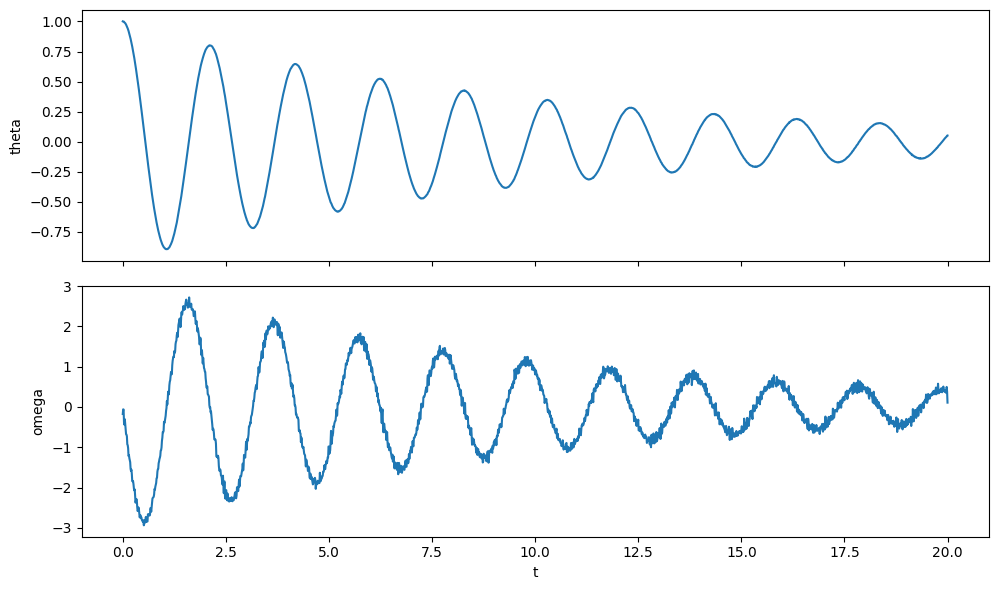

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, column in zip(axes, ["theta", "omega"]):
    ax.plot(pendulum_df["t"], pendulum_df[column])
    ax.set_ylabel(column)
axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

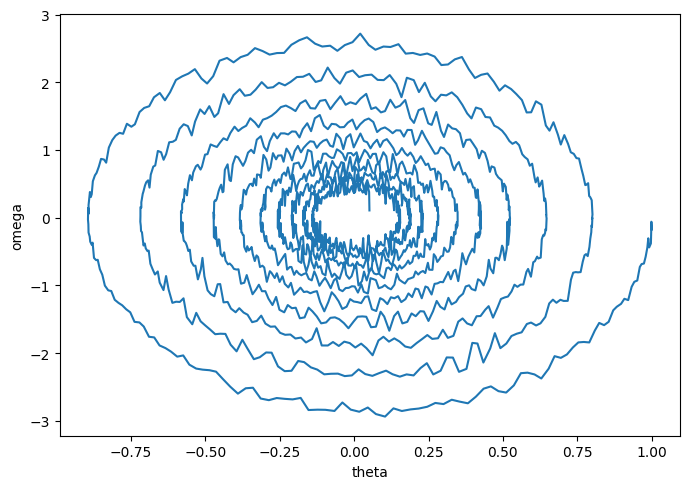

In [36]:
plt.figure(figsize=(7, 5))
plt.plot(pendulum_df["theta"], pendulum_df["omega"])
plt.xlabel("theta")
plt.ylabel("omega")
plt.tight_layout()
plt.show()

### Pendulum Validation

In [11]:
pendulum_predicted_derivatives = predict_derivatives(
    pendulum_library,
    pendulum_coefficients,
)

for target in ["theta_dot", "omega_dot"]:
    rmse = np.sqrt(
        np.mean(
            (
                pendulum_derivatives[target].to_numpy()
                - pendulum_predicted_derivatives[target].to_numpy()
            ) ** 2
        )
    )
    print(f"{target} RMSE: {rmse:.6f}")

theta_dot RMSE: 0.000000
omega_dot RMSE: 306.119763


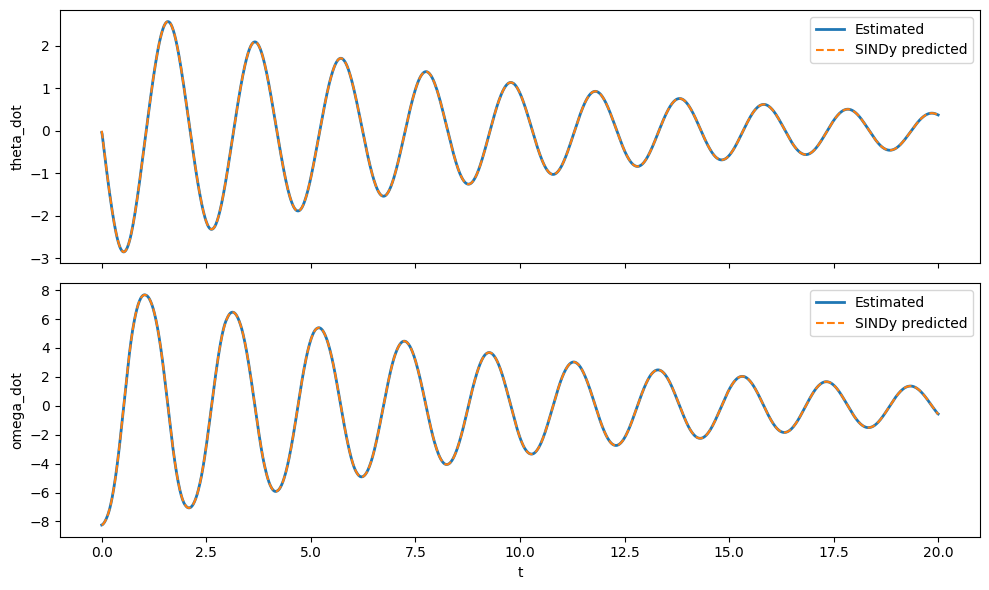

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, target in zip(axes, ["theta_dot", "omega_dot"]):
    ax.plot(
        pendulum_df["t"],
        pendulum_derivatives[target],
        label="Estimated",
        linewidth=2,
    )
    ax.plot(
        pendulum_df["t"],
        pendulum_predicted_derivatives[target],
        label="SINDy predicted",
        linestyle="--",
    )
    ax.set_ylabel(target)
    ax.legend()

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()